['Age', 'Gender', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Department_arts', 'Department_business', 'Department_engineering', 'Department_medical', 'Department_science']
Accuracy: 0.8990
Antes de SMOTE:
Depression
False    71950
True      8050
Name: count, dtype: int64

Después de SMOTE:
Depression
False    71950
True     71950
Name: count, dtype: int64
Modelo y scaler guardados correctamente

Accuracy: 0.6825


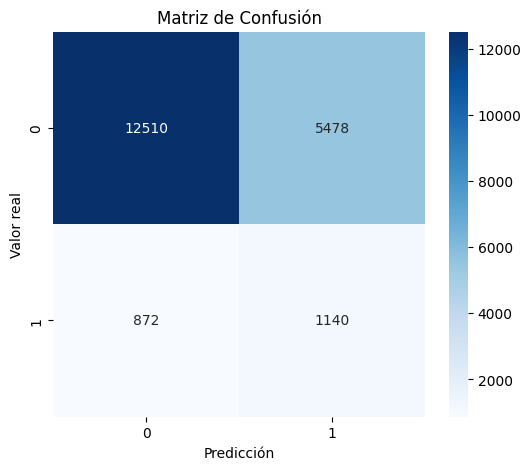


Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.93      0.70      0.80     17988
        True       0.17      0.57      0.26      2012

    accuracy                           0.68     20000
   macro avg       0.55      0.63      0.53     20000
weighted avg       0.86      0.68      0.74     20000



In [1]:
# Importar librerías
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# =========================
# CARGAR DATASET
# =========================
df = pd.read_csv("/content/student_lifestyle_100k.csv")

# =========================
# LIMPIEZA DE DATOS
# =========================
df["Department"] = df["Department"].astype(str).str.strip().str.lower()

df = pd.get_dummies(df, columns=["Department"], drop_first=False)

df.drop(columns=["Student_ID"], inplace=True)

df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()

df.loc[df["Gender"] == "male", "Gender"] = 0
df.loc[df["Gender"] == "female", "Gender"] = 1

df["Gender"] = df["Gender"].astype(int)


y = df["Depression"]
X = df.drop(columns=["Depression"])
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)



model.fit(X_train, y_train)



score = model.score(X_test, y_test)

print(f'Accuracy: {score:.4f}')



print("Antes de SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDespués de SMOTE:")
print(pd.Series(y_train_bal).value_counts())


model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

# Entrenar
model.fit(X_train_bal, y_train_bal)

joblib.dump(model, "modelo_smote.pkl")
joblib.dump(scaler, "scaler_smote.pkl")


print("Modelo y scaler guardados correctamente")

score = model.score(X_test, y_test)

print(f"\nAccuracy: {score:.4f}")

# Predicciones
y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()


print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))